## Distance Metrics Execercise

# (Part 1): Distance Metrics and Similarity Analysis
1.4.1 Tasks 
1. Implement the following distance functions that compute the distance between two data points in an
n-dimensional space:
• L1 (Manhattan) Distance
• L2 (Euclidean) Distance
• Cosine Distance
2. Using the first 100 houses in the dataset, compute all pairwise distances for each distance metric.
3. For each metric, estimate:
• The mean of the pairwise distances\n
• The standard deviation of the pairwise distances
4. Visualize the distribution of distances for each metric using a plotting library of your choice (e.g.,
histograms, density plots).

In [1079]:
import pandas as pd
import numpy as np
from sklearn import datasets 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

In [1080]:
## Loading the dataset
houses_df = pd.read_csv('house_prices.csv')
houses_df.head()

,house_price,area,nb_bedrooms,nb_bathrooms,nb_stories,mainroad,nb_guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [1081]:
# Displaying dataset structure, data types, and non-null counts
houses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   house_price       545 non-null    int64 
 1   area              545 non-null    int64 
 2   nb_bedrooms       545 non-null    int64 
 3   nb_bathrooms      545 non-null    int64 
 4   nb_stories        545 non-null    int64 
 5   mainroad          545 non-null    object
 6   nb_guestroom      545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [1082]:
# Show summary statistics for numerical columns
houses_df.describe()

,house_price,area,nb_bedrooms,nb_bathrooms,nb_stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Basic Data Preparation

In [1083]:
##Encode Categorical Columns
#building a pipeline to automate two types of features: numeric vs categorical using label encoding

In [1084]:
houses_numeric = []
houses_categorical = []
for colx in houses_df.columns:
  if houses_df[colx].dtype == 'object':
    #print(colx, df[colx].nunique())
    houses_categorical.append(colx)
  else:
    houses_numeric.append(colx)
print('numeric features:', houses_numeric)
print('categorical features:', houses_categorical)

numeric features: ['house_price', 'area', 'nb_bedrooms', 'nb_bathrooms', 'nb_stories', 'parking']
categorical features: ['mainroad', 'nb_guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


## Label encoding

In [1085]:
# Encode categorical features into numeric labels for modeling
encoded_df = houses_df.copy()

label_encoder = LabelEncoder()
for featx in houses_categorical:
  encoded_df[featx] = label_encoder.fit_transform(encoded_df[featx])

In [1086]:
encoded_df.head()

,house_price,area,nb_bedrooms,nb_bathrooms,nb_stories,mainroad,nb_guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [1087]:
encoded_df.shape

(545, 13)

In [1088]:
encoded_df.columns

Index(['house_price', 'area', 'nb_bedrooms', 'nb_bathrooms', 'nb_stories',
       'mainroad', 'nb_guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [1089]:
#checking if you have missing value
encoded_df.isna().sum()

house_price         0
area                0
nb_bedrooms         0
nb_bathrooms        0
nb_stories          0
mainroad            0
nb_guestroom        0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [1090]:
encoded_df.head()

,house_price,area,nb_bedrooms,nb_bathrooms,nb_stories,mainroad,nb_guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [1091]:
# Standardize features to have mean 0 and standard deviation 1
X = (X - X.mean(axis=0)) / X.std(axis=0)

This is done to standardize the features, putting them on the same scale so that no single feature dominates due to its magnitude. It is especially important for distance-based models like k-NN, because they rely on distances between points, and unscaled features can bias the model toward variables with larger ranges.

In [1092]:
# Generate all possible pairs of indices from the dataset for pairwise comparisons
pairs = list(itertools.combinations(range(len(X)), 2))

Generating pairs allows for computation of pairwise distances or similarities between all data points in the dataset.
By creating all possible pairs, we can analyze relationships, distributions, or patterns across the dataset.
This is essential for tasks like distance analysis, clustering, or nearest-neighbor calculations.

In [1093]:
# Computing Manhattan distance between the 'area' of point i and 'nb_bedrooms' of point j for all pairs
distances = []

for i, j in pairs:
    x1 = X[i, 0]   # area
    x2 = X[j, 1]   # nb_bedrooms
    
    l1_distance = np.abs(x1 - x2)
    distances.append((i, j, l1_distance))

In [1094]:
# Display the first 5 computed distances
distances[:5]

[(0, 1, np.float64(2.8093556001355733)),
 (0, 2, np.float64(2.3481327186432472)),
 (0, 3, np.float64(3.4827410071143703)),
 (0, 4, np.float64(3.5196388376337557)),
 (0, 5, np.float64(3.4827410071143703))]

In [1095]:
# L1 distance
l1_distance = np.sum(np.abs(x1 - x2))
print("L1 Distance:", l1_distance)

L1 Distance: 1.0144873501937786


In [1096]:
# L2 distance
l2_distance = np.sqrt(np.sum((x1 - x2) ** 2))
print("L2 Distance:", l2_distance)

L2 Distance: 1.0144873501937786


In [1097]:
# Cosine similarity
cos_sim = np.dot(x1, x2) / (np.linalg.norm(x1) * np.linalg.norm(x2))
cos_dist = 1 - cos_sim

print("Cosine Similarity:", cos_sim)
print("Cosine Distance:", cos_dist)

Cosine Similarity: 1.0
Cosine Distance: 0.0


## Using the first 100 houses in the dataset, compute all pairwise distances for each distance metric

In [1098]:
data = encoded_df.select_dtypes(include=np.number).iloc[:100, :].values

In [1099]:
#Manhattan (L1) distance
def l1_distance(x, y):
    
    return np.sum(np.abs(x - y))
    
#Euclidean (L2) distance
def l2_distance(x, y):
    
    return np.sqrt(np.sum((x - y) ** 2))
    
#Cosine distance
def cosine_distance(x, y):
    
    return 1 - (np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y)))

In [1100]:
# Generating all unique pairs of data point indices
indices = list(range(data.shape[0]))  # 0 to 99
pairs = list(itertools.combinations(indices, 2))

In [1101]:
 #Compute pairwise distances for each metric
l1_distances = np.array([l1_distance(data[i], data[j]) for i, j in pairs])
l2_distances = np.array([l2_distance(data[i], data[j]) for i, j in pairs])
cosine_distances = np.array([cosine_distance(data[i], data[j]) for i, j in pairs])

In [1102]:
#Printing number of pairs
print("Number of pairs:", len(pairs)) 

Number of pairs: 4950


In [1103]:
#Compute mean and standard deviation for each metric
print("Pairwise Distance Statistics (First 100 Houses):\n")
print(f"L1 (Manhattan) Distance: Mean = {l1_distances.mean():.4f}, Std = {l1_distances.std():.4f}")
print(f"L2 (Euclidean) Distance: Mean = {l2_distances.mean():.4f}, Std = {l2_distances.std():.4f}")
print(f"Cosine Distance: Mean = {cosine_distances.mean():.4f}, Std = {cosine_distances.std():.4f}")

Pairwise Distance Statistics (First 100 Houses):

L1 (Manhattan) Distance: Mean = 1561109.6875, Std = 1410600.3285
L2 (Euclidean) Distance: Mean = 1558956.1932, Std = 1410373.6769
Cosine Distance: Mean = 0.0000, Std = 0.0000


Text(0, 0.5, 'Frequency')

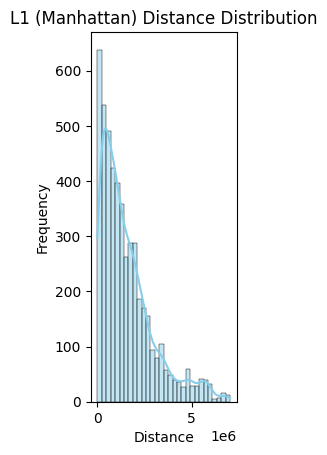

In [1104]:
# L1 (Manhattan) distance
plt.subplot(1, 3, 1)
sns.histplot(l1_distances, bins=30, kde=True, color='skyblue')
plt.title("L1 (Manhattan) Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

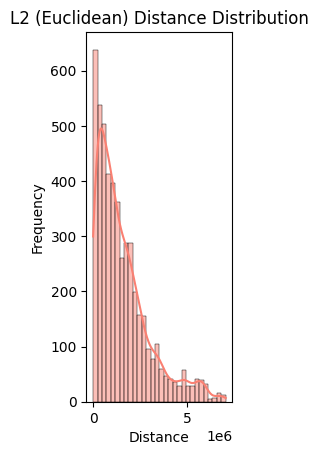

In [1105]:
# L2 (Euclidean) distance
plt.subplot(1, 3, 2)
sns.histplot(l2_distances, bins=30, kde=True, color='salmon')
plt.title("L2 (Euclidean) Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

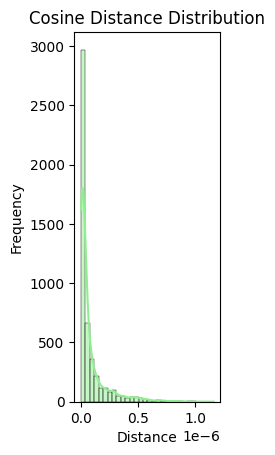

In [1106]:
# Cosine distance
plt.subplot(1, 3, 3)
sns.histplot(cosine_distances, bins=30, kde=True, color='lightgreen')
plt.title("Cosine Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")



##




## (Part 2): k-Nearest Neighbors (k-NN) Regression

 Using the same dataset, build a k-Nearest Neighbors regression model with the following specifications:
 • Use a 50%–50% train/test split.
The target (dependent) variable is house price.
Clearly state the value(s) of k used in your analysis.

# Tasks

1. Train a k-NN regression model on the training data.
2. Evaluate model performance on the test set using at least one appropriate regression metric (e.g.,
RMSE, MAE, R2).
3. Briefly discuss how the choice of distance metric and k may influence model performance.

## Test Train split

In [1107]:
#splitting our values into training and testing datasets #ensure you import traintest split
x = encoded_df
y = x.pop("house_price")

In [1108]:
x.head()

,area,nb_bedrooms,nb_bathrooms,nb_stories,mainroad,nb_guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0


In [1109]:
#target removed so column numbers reduce
x.shape

(545, 12)

In [1110]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: house_price, dtype: int64

In [1111]:
#Checking for unique house prices
y.unique()

array([13300000, 12250000, 12215000, 11410000, 10850000, 10150000,
        9870000,  9800000,  9681000,  9310000,  9240000,  9100000,
        8960000,  8890000,  8855000,  8750000,  8680000,  8645000,
        8575000,  8540000,  8463000,  8400000,  8295000,  8190000,
        8120000,  8080940,  8043000,  7980000,  7962500,  7910000,
        7875000,  7840000,  7700000,  7560000,  7525000,  7490000,
        7455000,  7420000,  7350000,  7343000,  7245000,  7210000,
        7140000,  7070000,  7035000,  7000000,  6930000,  6895000,
        6860000,  6790000,  6755000,  6720000,  6685000,  6650000,
        6629000,  6615000,  6580000,  6510000,  6475000,  6440000,
        6419000,  6405000,  6300000,  6293000,  6265000,  6230000,
        6195000,  6160000,  6125000,  6107500,  6090000,  6083000,
        6020000,  5950000,  5943000,  5880000,  5873000,  5866000,
        5810000,  5803000,  5775000,  5740000,  5652500,  5600000,
        5565000,  5530000,  5523000,  5495000,  5460000,  5425

In [1112]:
# Display all column names in the encoded DataFrame
print(encoded_df.columns)

Index(['area', 'nb_bedrooms', 'nb_bathrooms', 'nb_stories', 'mainroad',
       'nb_guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [1113]:
#Splitting our data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.5, random_state=42)

In [1114]:
# Showing the shape of the training feature set (rows, columns)
x_train.shape

(272, 12)

In [1115]:
# Show the shape of the test feature set (rows, columns)
x_test.shape

(273, 12)

## Train Classifier

 knn neighbors Regressor is imported before starting this section

In [1116]:
# Initialize a k-NN regressor 
knn = KNeighborsRegressor(n_neighbors=3)

In [1117]:
#Training our model
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [1118]:
#Checking the accuracy of the model based on the test scores
knn.score(x_test, y_test)

0.3061051189669044

## Tunning Sensitivity of Model To n_neighbors


At this stage we import matplotlib to plot the outcome

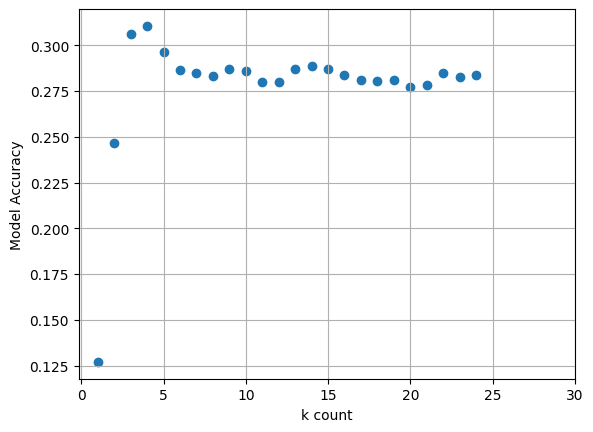

In [1119]:
#Here regression metric  R² (coefficient of determination) is implemented 
# This is to evaluate how well the k-NN regression model explains the variance in the target variable for different values of k
k_range = range(1, 25)
scores = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    scores.append(knn.score(x_test, y_test))

plt.figure()
plt.xlabel("k count")
plt.ylabel("Model Accuracy")
plt.scatter(k_range, scores)
plt.grid()
plt.xticks([0, 5, 10, 15, 20, 25, 30])
plt.show()

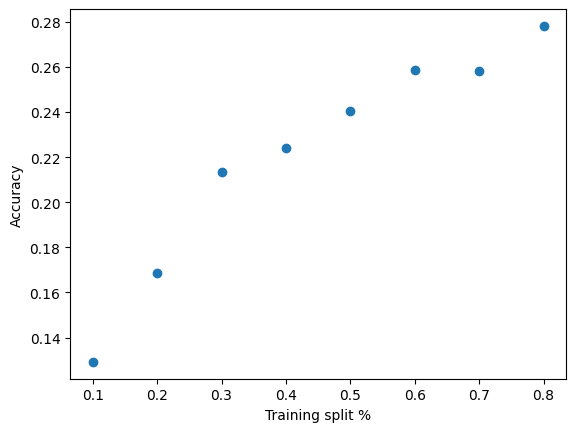

In [1120]:
#evaluating how a k-NN regressor (k=3) performs across different training–testing split ratios 
#by repeatedly training the model and averaging its accuracy for each split
test_sizes = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
knn = KNeighborsRegressor(n_neighbors=3)

mean_scores = []  

for test_size in test_sizes:
    scores = []
    for i in range(1, 100):
        x_train, x_test, y_train, y_test = train_test_split(
            x, y, test_size=1 - test_size
        )
        knn.fit(x_train, y_train)
        scores.append(knn.score(x_test, y_test))
    
    mean_scores.append(np.mean(scores))  
    
#visualizing the relationship between training data proportion and mean model performance
plt.figure()
plt.plot(test_sizes, mean_scores, marker='o', linestyle='None')


plt.xlabel("Training split %")
plt.ylabel("Accuracy")
plt.show()


## Make Predictions

In [1121]:
## Use the trained k-NN model to predict target values for the test set
prediction = knn.predict(x_test)

In [1122]:
prediction

array([5880000.        , 6615000.        , 4153333.33333333,
       4428666.66666667, 3283000.        , 3266666.66666667,
       3283000.        , 2800000.        , 4911666.66666667,
       5142666.66666667, 5226666.66666667, 3283000.        ,
       4491666.66666667, 4428666.66666667, 4153333.33333333,
       5142666.66666667, 4421666.66666667, 2800000.        ,
       2800000.        , 5215000.        , 3241000.        ,
       5142666.66666667, 4456666.66666667, 6311666.66666667,
       5553333.33333333, 4153333.33333333, 4888333.33333333,
       5950000.        , 6615000.        , 3266666.66666667,
       6615000.        , 3266666.66666667, 4911666.66666667,
       3756666.66666667, 5880000.        , 4153333.33333333,
       7765333.33333333, 5553333.33333333, 4349333.33333333,
       5343333.33333333, 4153333.33333333, 5950000.        ,
       4428666.66666667, 4742500.        , 3756666.66666667,
       7765333.33333333, 6090000.        , 5950000.        ,
       4001666.66666667,

In [1123]:
# Display the target values for the test set
y_test

164    5390000
205    4900000
278    4277000
460    3087000
507    2590000
        ...   
256    4480000
91     6419000
255    4480000
333    3920000
182    5145000
Name: house_price, Length: 491, dtype: int64

## Briefly discuss how the choice of distance metric and k may influence model performance.

The choice of distance metric and the number of neighbors (k) fundamentally shape a model's boundary and performance. Metrics like Euclidean (straight-line) or Manhattan (grid-based) define similarity; choosing an inappropriate one can lead to poor, unrepresentative clustering. Smaller (k) values increase sensitivity to noise (overfitting) for example in the above model when k=2 the accuracy is 0.24683317651033898 lower accuracy compared to K=3 which is used here with an accuracy of , while larger (k) values create overly smooth, biased, and potentially less accurate boundaries for example for k=5 the accuracy is 0.2992223564879011, k=6 is 0.2863172139203791 showing a further reduction. So an orp